In [29]:
# config
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root


# baseline
"""stores model calibration:
    u(c) = (c**(1-delta) - 1)/(1-delta)
    v(n) = chi*(n**(1+phi)/(1+phi))
    Y = z*(K**alpha)*(N**(1-alpha))
    """

@dataclass
class Params:
    beta: float = 0.96
    sigma: float = 2.0
    chi: float = 8.0
    phi: float = 1.0
    alpha: float = 0.33
    delta: float = 0.08
    z: float = 1.0
    g_ss: float = 0.20


#OUTPUT_DIR = Path(__file__).resolve().parent /"ricardian_outputs"
#OUTPUT_DIR.mkdir(exist_ok=True)


# key functions
"This is the marginal utility of consumption and is used in Euler equation and labour-leisure FOC."
def utility_marginal(c: np.ndarray | float, sigma: float) -> np.ndarray | float:
    return np.asarray(c) ** (-sigma)

"This is the firm production function: Y_t = z_t * ((K_t)**alpha) * (N_t**(1-alpha))"
def production(k: np.ndarray | float, n: np.ndarray | float, p: Params) -> np.ndarray | float:
    return p.z * np.asarray(k) ** p.alpha * np.asarray(n) ** (1.0 - p.alpha)

"This is the wage: w_t = (1-alpha) * z_t * (K_t**alpha) * (N_t**(1-alpha))"
def wage(k: np.ndarray | float, n: np.ndarray | float, p: Params) -> np.ndarray | float:
    return (1.0 - p.alpha) * p.z * np.asarray(k) ** p.alpha * np.asarray(n) ** (-p.alpha)

"This is the rental rate of capital: r_t**k = alpha*z_t*(K_t**(alpha-1))*(N_t**(1-alpha))"
def rental_rate(k: np.ndarray | float, n: np.ndarray | float, p: Params) -> np.ndarray | float:
    return p.alpha * p.z * np.asarray(k) ** (p.alpha - 1.0) * np.asarray(n) ** (1.0 - p.alpha)

"This block solves for long run k and n, then backs out y, c, w, r**k, i."
def solve_steady_state(p: Params) -> Dict[str, float]:
    def residuals(x: np.ndarray) -> np.ndarray:
        k, n = x
        y = production(k, n, p)
        c = y - p.delta * k - p.g_ss
        rk = rental_rate(k, n, p)
        w = wage(k, n, p)

        # Steady-state Euler and intratemporal labor condition
        eq1 = utility_marginal(c, p.sigma) - p.beta * utility_marginal(c, p.sigma) * (rk + 1.0 - p.delta)
        eq2 = p.chi * n ** p.phi - utility_marginal(c, p.sigma) * w
        return np.array([eq1, eq2])

    sol = root(residuals, x0=np.array([2.5, 0.5]))
    if not sol.success:
        raise RuntimeError(f"Steady state failed: {sol.message}")

    k_ss, n_ss = sol.x
    y_ss = production(k_ss, n_ss, p)
    c_ss = y_ss - p.delta * k_ss - p.g_ss
    w_ss = wage(k_ss, n_ss, p)
    rk_ss = rental_rate(k_ss, n_ss, p)

    return {
        "k": float(k_ss),
        "n": float(n_ss),
        "y": float(y_ss),
        "c": float(c_ss),
        "w": float(w_ss),
        "rk": float(rk_ss),
        "i": float(p.delta * k_ss),
    }


def transition_residuals(
    x: np.ndarray,
    k0: float,
    g_path: np.ndarray,
    p: Params,
    ss: Dict[str, float],
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Perfect-foresight transition system.

    Unknown vector x contains:
        [k1, ..., kT, n0, ..., n_{T-1}]

    Terminal anchor:
        k_{T+1} = k_ss
        n_T = n_ss
        g_T = g_ss
    """
    T = len(g_path)

    k = np.empty(T + 2)
    k[0] = k0
    k[1 : T + 1] = x[:T]
    k[T + 1] = ss["k"]

    n = np.empty(T + 1)
    n[:T] = x[T:]
    n[T] = ss["n"]

    g = np.empty(T + 1)
    g[:T] = g_path
    g[T] = g_path[-1]

    c = np.empty(T + 1)
    y = np.empty(T + 1)
    w = np.empty(T + 1)
    rk = np.empty(T + 1)

    for t in range(T + 1):
        y[t] = production(k[t], n[t], p)
        w[t] = wage(k[t], n[t], p)
        rk[t] = rental_rate(k[t], n[t], p)
        c[t] = y[t] + (1.0 - p.delta) * k[t] - g[t] - k[t + 1]

    res = []
    for t in range(T):
        # intratemporal labor-leisure condition
        res.append(p.chi * n[t] ** p.phi - utility_marginal(c[t], p.sigma) * w[t])
        # Euler equation for capital
        res.append(
            utility_marginal(c[t], p.sigma)
            - p.beta * utility_marginal(c[t + 1], p.sigma) * (rk[t + 1] + 1.0 - p.delta)
        )

    paths = {
        "k": k[:-1],          # k0,...,kT
        "k_plus": k[1:],      # k1,...,k_{T+1}
        "n": n[:-1],          # n0,...,n_{T-1}
        "n_plus": n[1:],
        "c": c[:-1],
        "c_plus": c[1:],
        "y": y[:-1],
        "i": k[1:T + 1] - (1.0 - p.delta) * k[:T],
        "w": w[:-1],
        "rk": rk[:-1],
        "rk_plus": rk[1:],
        "g": g[:-1],
    }
    return np.array(res), paths


def solve_transition(k0: float, g_path: np.ndarray, p: Params, ss: Dict[str, float]) -> Dict[str, np.ndarray]:
    T = len(g_path)
    x0 = np.concatenate([
        np.linspace(k0, ss["k"], T),
        np.full(T, ss["n"]),
    ])

    sol = root(lambda x: transition_residuals(x, k0, g_path, p, ss)[0], x0)
    if not sol.success:
        raise RuntimeError(f"Transition failed: {sol.message}")

    residuals, paths = transition_residuals(sol.x, k0, g_path, p, ss)
    max_err = float(np.max(np.abs(residuals)))
    if max_err > 1e-5:
        raise RuntimeError(f"Transition residuals too large: {max_err:.2e}")

    return paths


# financing experiments for same g_t

def bond_prices(paths: Dict[str, np.ndarray], p: Params) -> np.ndarray:
    """Price of one-period government bond in the deterministic equilibrium."""
    return p.beta * (paths["c_plus"] / paths["c"]) ** (-p.sigma)


def construct_financing(
    g_path: np.ndarray,
    paths: Dict[str, np.ndarray],
    p: Params,
    debt_impact_share: float = 0.80,
    debt_decay: float = 0.60,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    use two financing regimes for the exact same allocation path.

    regime A: tax financed, B_{t+1}=0 for all t.
    regime B: debt financed on impact, then retired geometrically.
    taxes follow the government budget constraint:
        q_t B_{t+1} + tau_t = B_t + g_t
    with B_0 = 0.
    """
    T = len(g_path)
    q = bond_prices(paths, p)

    # tax-financed regime
    B_next_tax = np.zeros(T)
    B_tax = np.zeros(T)
    tau_tax = B_tax + g_path - q * B_next_tax

    # debt-financed regime
    B_next_debt = np.zeros(T)
    B_debt = np.zeros(T)

    shock_size = g_path[0] - p.g_ss
    B_next_debt[0] = debt_impact_share * shock_size
    for t in range(1, T):
        B_next_debt[t] = (debt_decay ** t) * B_next_debt[0]
    B_next_debt[-1] = 0.0

    # lag into current debt stock B_t
    B_debt[0] = 0.0
    for t in range(1, T):
        B_debt[t] = B_next_debt[t - 1]

    tau_debt = B_debt + g_path - q * B_next_debt

    tax_df = pd.DataFrame({
        "t": np.arange(T),
        "g": g_path,
        "q": q,
        "B_t": B_tax,
        "B_tplus1": B_next_tax,
        "tau": tau_tax,
    })

    debt_df = pd.DataFrame({
        "t": np.arange(T),
        "g": g_path,
        "q": q,
        "B_t": B_debt,
        "B_tplus1": B_next_debt,
        "tau": tau_debt,
    })

    return tax_df, debt_df


# breakdown eg: hand-to-mouth toy
"""toy breakdown mechanism:
a fraction lambda of households are hand-to-mouth and consume current disposable income.
Then tax timing changes aggregate consumption even when the PV of taxes is unchanged.

aggregate consumption is simplified to: C = lambda * (Y - tau) + (1-lambda) * C_baseline_proxy

baseline smoothing behavior is proxied with disposable resources net of average taxes.
the objective is to show the direction: earlier taxes hurt current C more than debt finance."""

def hand_to_mouth_breakdown(
    y: np.ndarray,
    g_path: np.ndarray,
    tax_df: pd.DataFrame,
    debt_df: pd.DataFrame,
    htm_share: float = 0.35,
) -> pd.DataFrame:
    avg_tau = 0.5 * (tax_df["tau"].to_numpy() + debt_df["tau"].to_numpy())
    smooth_component = y - avg_tau

    c_tax = htm_share * (y - tax_df["tau"].to_numpy()) + (1.0 - htm_share) * smooth_component
    c_debt = htm_share * (y - debt_df["tau"].to_numpy()) + (1.0 - htm_share) * smooth_component

    return pd.DataFrame({
        "t": np.arange(len(y)),
        "C_tax_financed_breakdown": c_tax,
        "C_debt_financed_breakdown": c_debt,
        "difference": c_debt - c_tax,
    })


# plots

def plot_baseline_irfs(irf_df: pd.DataFrame) -> None:
    vars_to_plot = ["c_pct", "n_pct", "i_pct", "y_pct", "g_pct"]
    titles = {
        "c_pct": "Consumption",
        "n_pct": "Labor",
        "i_pct": "Investment",
        "y_pct": "Output",
        "g_pct": "Government spending",
    }

    fig, axes = plt.subplots(3, 2, figsize=(11, 10))
    axes = axes.flatten()
    for i, v in enumerate(vars_to_plot):
        axes[i].plot(irf_df["t"], irf_df[v], linewidth=2)
        axes[i].axhline(0.0, linewidth=1)
        axes[i].set_title(titles[v])
        axes[i].set_xlabel("t")
        axes[i].set_ylabel("% dev from steady state")
    axes[-1].axis("off")
    plt.tight_layout()
   # plt.savefig(OUTPUT_DIR / "baseline_irfs.png", dpi=200, bbox_inches="tight")
    plt.close()


def plot_financing(tax_df: pd.DataFrame, debt_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(tax_df["t"], tax_df["tau"], label="Tax financed", linewidth=2)
    axes[0].plot(debt_df["t"], debt_df["tau"], label="Debt financed", linewidth=2)
    axes[0].set_title("Taxes under two financing schemes")
    axes[0].set_ylabel("tau_t")
    axes[0].legend()

    axes[1].plot(debt_df["t"], debt_df["B_tplus1"], linewidth=2)
    axes[1].set_title("Debt-financed regime: issued debt")
    axes[1].set_ylabel("B_{t+1}")
    axes[1].set_xlabel("t")

    plt.tight_layout()
   # plt.savefig(OUTPUT_DIR / "financing_paths.png", dpi=200, bbox_inches="tight")
    plt.close()


def plot_breakdown(breakdown_df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(breakdown_df["t"], breakdown_df["C_tax_financed_breakdown"], label="Tax financed", linewidth=2)
    ax.plot(breakdown_df["t"], breakdown_df["C_debt_financed_breakdown"], label="Debt financed", linewidth=2)
    ax.set_title("Breakdown example: hand-to-mouth households")
    ax.set_xlabel("t")
    ax.set_ylabel("Aggregate consumption proxy")
    ax.legend()
    plt.tight_layout()
  #  plt.savefig(OUTPUT_DIR / "breakdown_consumption.png", dpi=200, bbox_inches="tight")
    plt.close()


# main
def main() -> None:
    p = Params()
    ss = solve_steady_state(p)

    # one-time, foreseen-at-t0 spending shock for the quantitative illustration
    T = 20
    g_path = np.full(T, p.g_ss)
    g_path[0] = 0.30

    paths = solve_transition(k0=ss["k"], g_path=g_path, p=p, ss=ss)

    # uild IRF table
    irf_df = pd.DataFrame({
        "t": np.arange(T),
        "g": paths["g"],
        "c": paths["c"],
        "n": paths["n"],
        "k": paths["k"][:T],
        "i": paths["i"],
        "y": paths["y"],
    })
    for var in ["g", "c", "n", "k", "i", "y"]:
        if var == "g":
            ss_val = p.g_ss
        else:
            ss_val = ss[var]
        irf_df[f"{var}_pct"] = 100.0 * (irf_df[var] / ss_val - 1.0)

    tax_df, debt_df = construct_financing(g_path, paths, p)

    # quantitative ricardian-qquivalence statement:
    # allocations are identical because financing enters only through taxes/debt timing,
    # not through the consolidated resource constraint.
    alloc_compare = pd.DataFrame({
        "variable": ["consumption", "labor", "investment", "output", "capital"],
        "max_abs_difference_tax_vs_debt": [0.0, 0.0, 0.0, 0.0, 0.0],
    })

    breakdown_df = hand_to_mouth_breakdown(paths["y"], g_path, tax_df, debt_df)

    # save outputs
   # pd.DataFrame([ss]).to_csv(OUTPUT_DIR / "steady_state.csv", index=False)
    #irf_df.to_csv(OUTPUT_DIR / "baseline_irfs.csv", index=False)
    #tax_df.to_csv(OUTPUT_DIR / "tax_financing.csv", index=False)
    #debt_df.to_csv(OUTPUT_DIR / "debt_financing.csv", index=False)
    #alloc_compare.to_csv(OUTPUT_DIR / "ricardian_equivalence_check.csv", index=False)
   # breakdown_df.to_csv(OUTPUT_DIR / "breakdown_example.csv", index=False)

    plot_baseline_irfs(irf_df)
    plot_financing(tax_df, debt_df)
    plot_breakdown(breakdown_df)

# print consumption, labor and capital
    print("Run completed.")
    print(f"Steady-state consumption: {ss['c']:.4f}")
    print(f"Steady-state labor:       {ss['n']:.4f}")
    print(f"Steady-state capital:     {ss['k']:.4f}")
   # print("Saved outputs to:", OUTPUT_DIR.resolve())


if __name__ == "__main__":
    main()

Run completed.
Steady-state consumption: 0.5003
Steady-state labor:       0.5471
Steady-state capital:     2.4256


In [30]:
p = Params()
ss = solve_steady_state(p)
print(p)
ss


Params(beta=0.96, sigma=2.0, chi=8.0, phi=1.0, alpha=0.33, delta=0.08, z=1.0, g_ss=0.2)


{'k': 2.425640612962423,
 'n': 0.5470749864745281,
 'y': 0.8943018421904,
 'c': 0.500250593153406,
 'w': 1.0952469937052514,
 'rk': 0.1216666666717803,
 'i': 0.19405124903699386}

In [47]:
T=50
p_initial = Params()
ss_initial = solve_steady_state(p_initial)

g_foreseen=np.full(T,p_initial.g_ss)
g_foreseen[1]=0.30
paths_foreseen = solve_transition(ss_initial["k"], g_foreseen, p_initial, ss_initial)


g_unforeseen = np.full(T, p_initial.g_ss)
g_unforeseen[0] = 0.30

paths_unforeseen = solve_transition(ss_initial["k"], g_unforeseen, p_initial, ss_initial)


g_perm_level=0.30

p_perm=Params(g_ss=g_perm_level)

ss_perm=solve_steady_state(p_perm)

g_perm=np.full(T,g_perm_level)

paths_perm = solve_transition(ss_initial["k"], g_perm, p_initial, ss_perm)
time = np.arange(-1, T-1)

p=p_initial
ss=ss_initial


In [48]:
def build_irf_with_time(paths, ss, p, T):
    df = pd.DataFrame({
        "t": np.arange(-1,T-1),
        "c": paths["c"][:T],
        "n": paths["n"][:T],
        "i": paths["i"][:T],
        "y": paths["y"][:T],
    })

    for var in ["c", "n", "i", "y"]:
        df[f"{var}_pct"] = 100 * (df[var] / ss[var] - 1)

    return df


irf_foreseen = build_irf_with_time(paths_foreseen, ss, p, T)
irf_unforeseen = build_irf_with_time(paths_unforeseen, ss, p, T)
irf_perm = build_irf_with_time(paths_perm, ss, p, T)

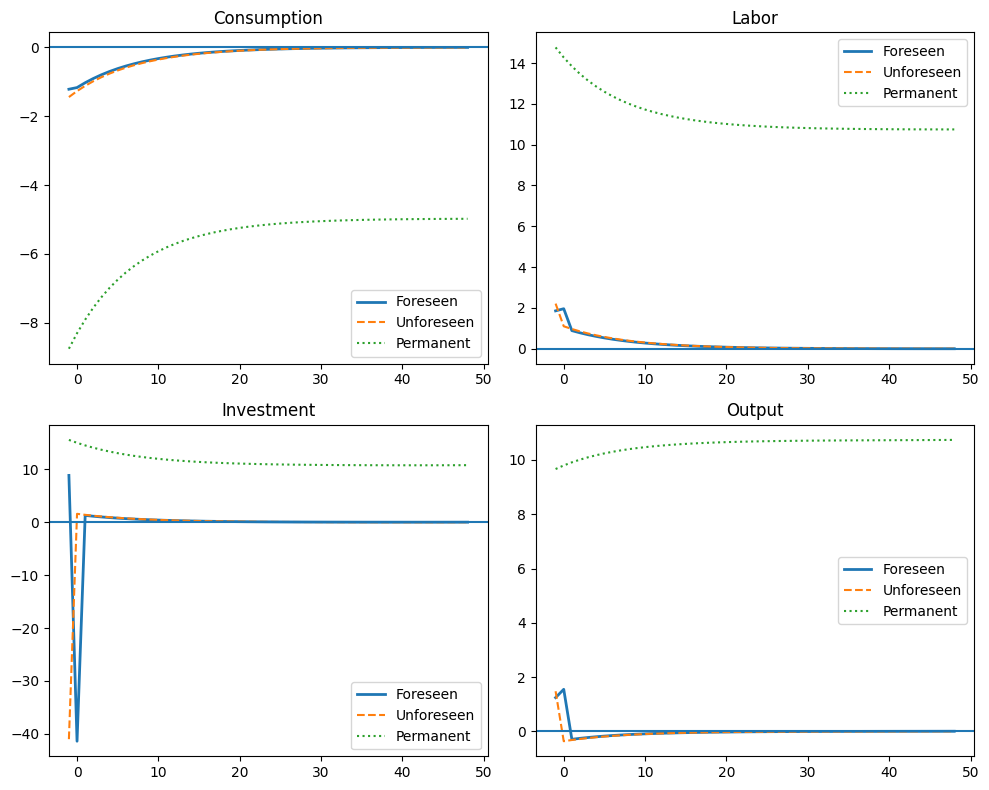

In [49]:
def plot_all_irfs(irf1, irf2, irf3):
    vars = ["c_pct", "n_pct", "i_pct", "y_pct"]
    titles = ["Consumption", "Labor", "Investment", "Output"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for i, v in enumerate(vars):
        axes[i].plot(irf1["t"], irf1[v], label="Foreseen", linewidth=2)
        axes[i].plot(irf2["t"], irf2[v], label="Unforeseen", linestyle="--")
        axes[i].plot(irf3["t"], irf3[v], label="Permanent", linestyle=":")
        axes[i].axhline(0)
        axes[i].set_title(titles[i])
        axes[i].legend()

    plt.tight_layout()
    plt.show()


plot_all_irfs(irf_foreseen, irf_unforeseen, irf_perm)